In [125]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
#from mpl_toolkits.basemap import Basemap
import numpy as np

In [126]:
DO_SAVE = False

# Define the path to your input raster file
input_raster_path = '/projects/my-public-bucket/tmp/SI35_1.tif'
out_fn = '/projects/my-public-bucket/tmp/SI35_1_rprj.tif'

In [ ]:


# Open the raster dataset
with rasterio.open(input_raster_path) as src:

    # Read metadata of the source raster
    src_crs = src.crs
    transform, width, height = calculate_default_transform(
        src.crs, 'EPSG:6931', src.width, src.height, *src.bounds)
    
    # Update the metadata to reflect the new CRS, transform, width, and height
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': 'EPSG:6931',
        #'crs': 'EPSG:3857',
        'transform': transform,
        'width': width,
        'height': height
    })
    
    # Create an in-memory destination raster dataset
    with rasterio.MemoryFile() as memfile:
        with memfile.open(**kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs='EPSG:6931',
                    resampling=Resampling.nearest,
                    dtype=rasterio.float32,
                    dst_nodata = 0)

            # Read the reprojected data for plotting
            reprojected_data = dst.read(1)
            print(dst.profile)
             # Use a generator instead of a list
            shape_gen = ((shape(s), v) for s, v in shapes(reprojected_data, transform=transform))

            # either build a pd.DataFrame
            # df = DataFrame(shape_gen, columns=['geometry', 'class'])
            # gdf = GeoDataFrame(df["class"], geometry=df.geometry, crs=src.crs)

            # or build a dict from unpacked shapes
            gdf = gpd.GeoDataFrame(dict(zip(["geometry", "class"], zip(*shape_gen))), crs=src.crs)
            
            if DO_SAVE:
                with rasterio.open(out_fn, 'w+',
                        driver='GTiff',
                        dtype= rasterio.float32,
                        count=dst.count,
                        crs = 'EPSG:6931',
                        width=dst.width,
                        height=dst.height,
                        transform=dst.transform,
                        nodata=dst.nodata

                    ) as dst:

                    for i in range(1, dst.count + 1):
                        #V = rescale_pct_clip(dst.read(band), pct=pct)
                        dst.write(dst.read(i),i)

In [142]:
import rioxarray
from geocube.vector import vectorize

data = rioxarray.open_rasterio(input_raster_path, mask_and_scale=True).squeeze()
data.name = "class"
#gdf = vectorize(data)
data

<xarray.DataArray 'class' (y: 54, x: 677)>
[36558 values with dtype=float64]
Coordinates:
    band         int64 1
  * x            (x) float64 -163.8 -163.3 -162.8 -162.3 ... 171.8 172.3 172.8
  * y            (y) float64 70.75 70.26 69.77 69.28 ... 46.22 45.73 45.24 44.75
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:     Area
    TIFFTAG_SOFTWARE:  MATLAB 9.13, Mapping Toolbox 5.4

In [7]:


# Mask the data where values are no data
masked_data = np.ma.masked_where(reprojected_data == np.nan, reprojected_data)


fig, ax = plt.subplots(figsize=(5, 5)
                       , subplot_kw={'projection': ccrs.NorthPolarStereo()}
                      )

#     # plot on the same axis with rio.plot.show
#     image = rasterio.plot.show(masked_data, 
#                           transform=transform, 
#                           ax=ax, 
#                           cmap='viridis', vmax=30)

# Show the reprojected raster data
#ax = rasterio.plot.show(masked_data, transform=transform, ax=ax, cmap='RdYlGn', vmin=0, vmax=30)
boreal = gpd.read_file('/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson')

# Add coastlines
#ax.coastlines(resolution="10m")
ax.imshow(masked_data, cmap='RdYlGn', vmin=0, vmax=30)
#ax=boreal.to_crs(ccrs.NorthPolarStereo()).plot(color='gray', ax=ax)

ctx.add_basemap(ax, crs = ccrs.NorthPolarStereo(), 
                source='http://services.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}', attribution=' ')


# add colorbar using the now hidden image
fig.colorbar(image_hidden, ax=ax, shrink=0.7)

plt.title('Boreal forest growth rates [SI35]')
plt.show()

NameError: name 'bandlist' is not defined

In [124]:
check_fn = '/projects/my-public-bucket/databank/extract_from_points/eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003.gpkg'
check_gdf = gpd.read_file(check_fn)
check_gdf.columns
(
 ggplot(check_gdf[['Ht_med', 'value_meta_alsgedi_global_v6']].dropna(), aes(x='Ht_med', y='value_meta_alsgedi_global_v6'))  
    +  geom_bin2d()
    #+ geom_abline()
)

/opt/conda/envs/pangeo/lib/python3.10/site-packages/plotnine/stats/stat_bin_2d.py:133: FutureWarning: The provided callable <function sum at 0x7f792d8af370> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


TypeError: cmap_pal.__init__() takes 2 positional arguments but 3 were given

In [108]:
check_gdf.shape

(990, 93)

/opt/conda/envs/pangeo/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 164 rows containing missing values.


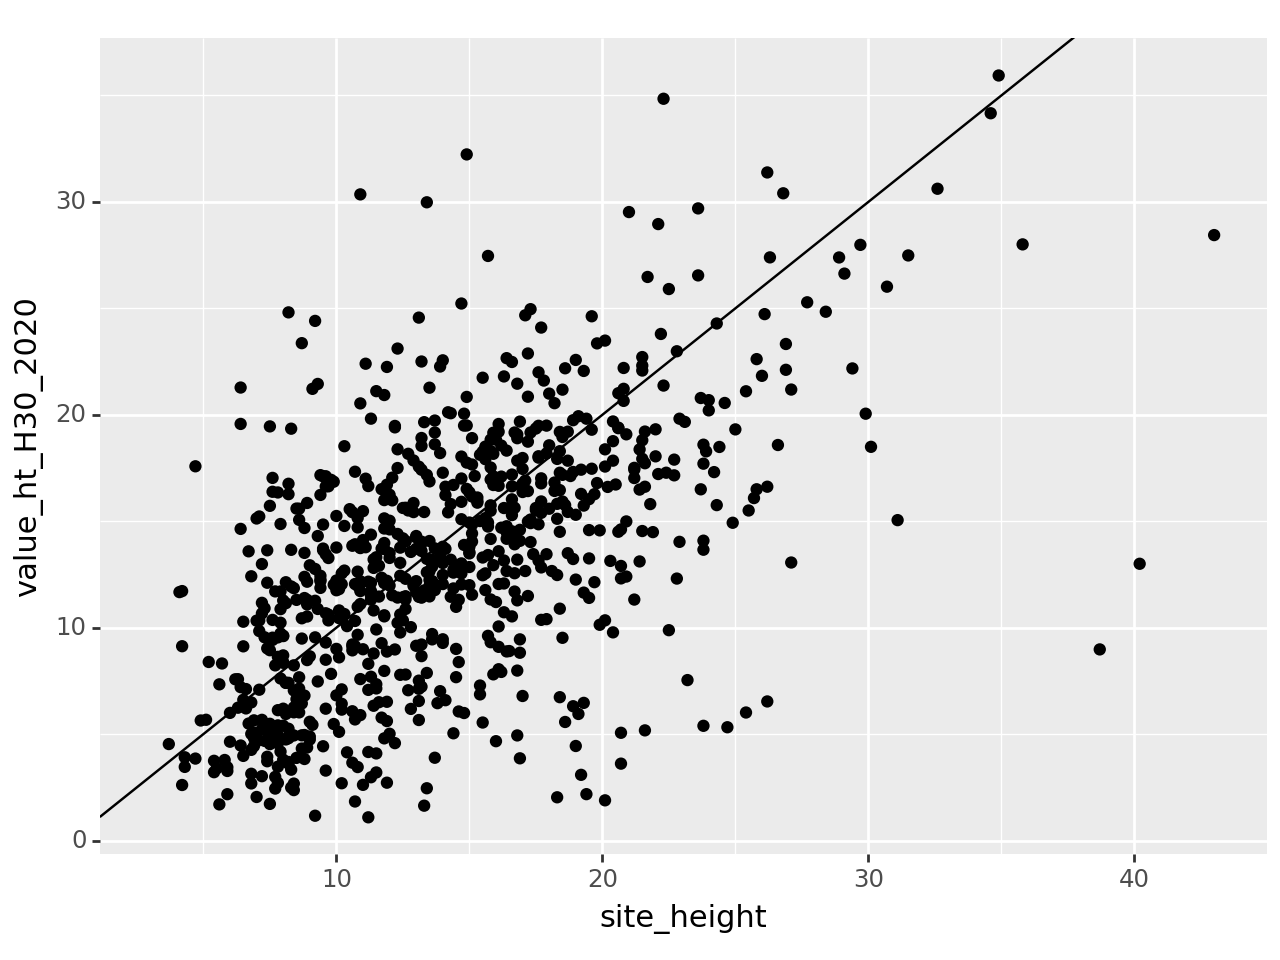

<Figure Size: (640 x 480)>

In [144]:
check_gdf = gpd.read_file('/projects/my-public-bucket/databank/extract_from_points/nfi_plus_20220603_s3_20240727.gpkg')
(
 ggplot(check_gdf, aes(x='site_height', y='value_ht_H30_2020'))  +
    geom_point()
    + geom_abline()
)

In [109]:
meta_gdf = gpd.read_file('/projects/my-public-bucket/databank/extract_from_points/nfi_plus_20220603_s3_20241003.gpkg')
print(meta_gdf.columns)
meta_gdf.shape

Index(['index', 'nfi_plot', 'meas_date_x', 'meas_num_x', 'plot_completion',
       'incomp_reason', 'province', 'ecozone', 'prov_eco_type', 'prov_eco_ref',
       'utm_n', 'utm_e', 'utm_zone', 'slope', 'aspect', 'elevation',
       'land_base', 'land_cover', 'land_pos', 'veg_type', 'density_cl',
       'stand_stru', 'succ_stage', 'wetland_class', 'user_info', 'ec_region',
       'ec_district', 'plotvol_standlive', 'plotvol_standdead',
       'plotvol_falllive', 'plotvol_smtr_live', 'plotvol_smtr_dead',
       'grossvol_incr', 'grossvol_mai', 'plotvol_stump', 'plotbio_stump',
       'plotbio_lgtr_live', 'plotbio_lgtr_dead', 'plotbio_smtr_live',
       'plotbio_smtr_dead', 'plotbio_shruherb', 'plotbio_bryo', 'plotbio_fwd',
       'plotvol_swd', 'plotbio_swd', 'plotvol_wd', 'plotbio_wd',
       'plotvol_roundwd', 'plotbio_roundwd', 'plotvol_oddwd', 'plotbio_oddwd',
       'plot_acc', 'meas_date_y', 'meas_num_y', 'plot_type', 'nom_plot_size',
       'meas_plot_size', 'plot_split', 'site_in

(987, 89)

In [100]:
import plotnine
from plotnine import *

/opt/conda/envs/pangeo/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 90 rows containing missing values.


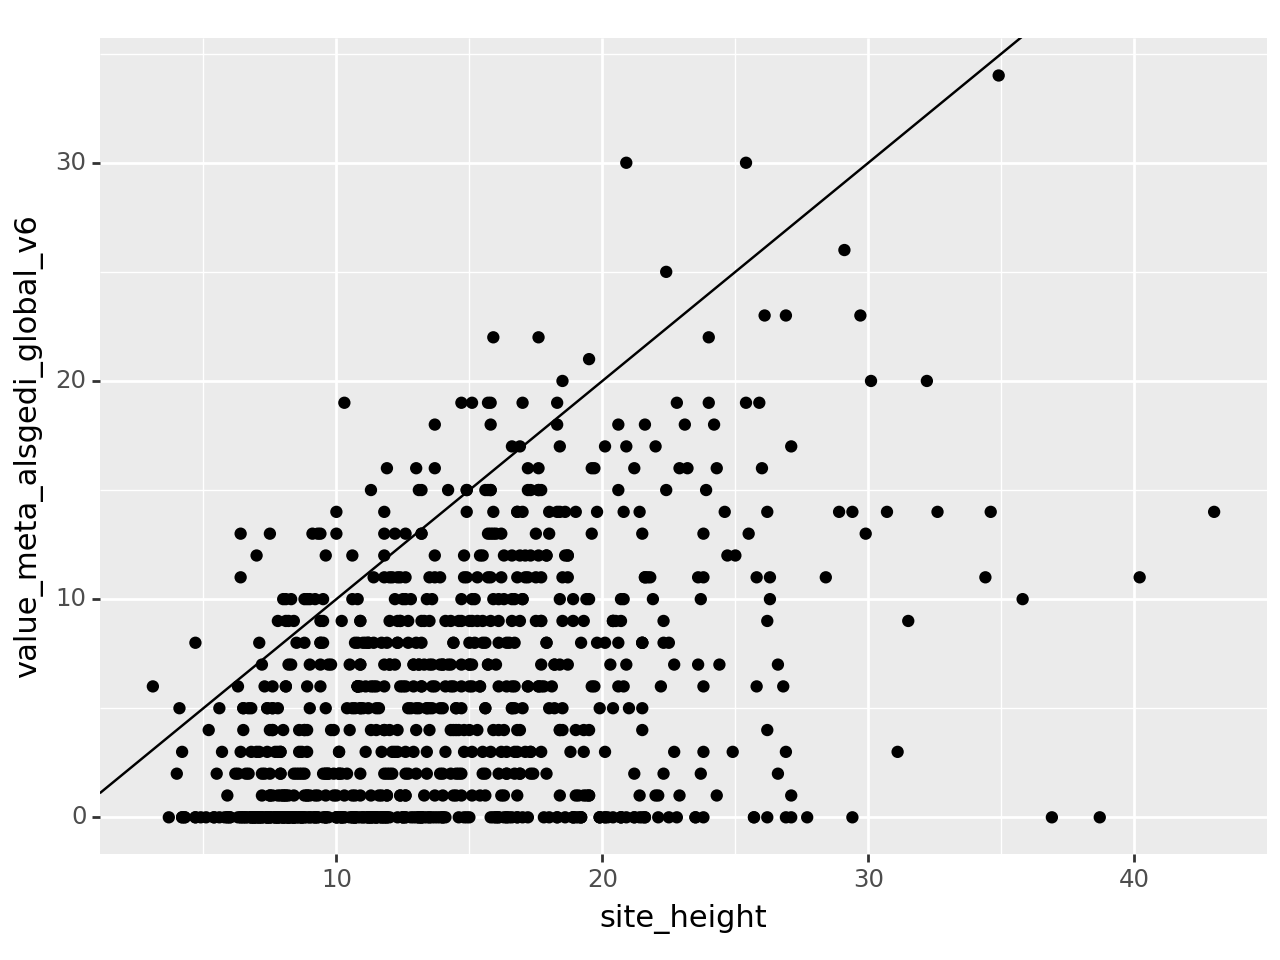

<Figure Size: (640 x 480)>

In [115]:
(
 ggplot(meta_gdf, aes(x='site_height', y='value_meta_alsgedi_global_v6'))  +
    geom_point()
    + geom_abline()
)

In [18]:
def show_raster(s3_path, MAX_VALID=100, VMAX=100, cmap='RdYlGn', title=''):
    
    ''' Show a raster on s3 or local with a colormap '''
    
    import matplotlib.pyplot as plt
    import rasterio
    from rasterio.plot import show, show_hist
    import numpy as np
    import numpy.ma as ma
    
    fig, ax = plt.subplots(figsize=(15, 5))
    
    with rasterio.env.Env(AWS_NO_SIGN_REQUEST = 'YES'):
        
        with rasterio.open(s3_path) as src:
            print(src.nodata)
            arr=src.read(1, masked=True)
            arr = ma.masked_where(arr>MAX_VALID, ma.masked_where(arr==0, arr))
            #show(arr, cmap=cmap)
            # use imshow so that we have something to map the colorbar to
            image_hidden = ax.imshow(arr, cmap=cmap)

            # plot on the same axis with rio.plot.show
            image = rasterio.plot.show(arr, 
                                  transform=src.transform, 
                                  ax=ax, 
                                  cmap=cmap, vmax=VMAX)
            
            ax.set_title(title)

            # add colorbar using the now hidden image
            fig.colorbar(image_hidden, ax=ax, shrink=0.8)

None


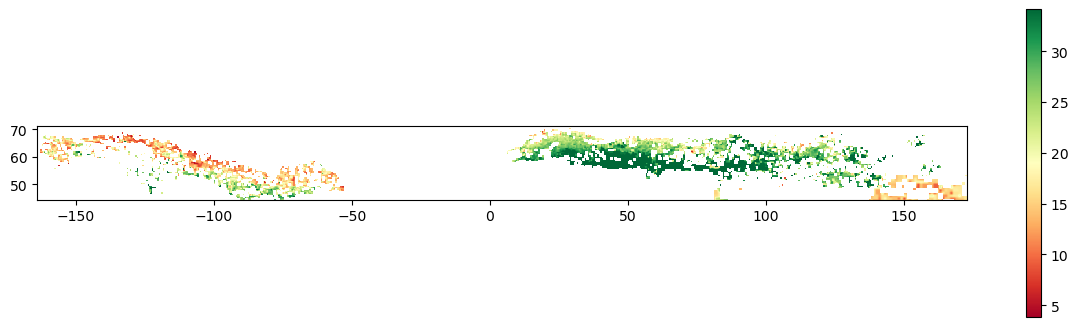

In [19]:
show_raster('s3://maap-ops-workspace/shared/montesano/tmp/' + os.path.basename(input_raster_path), MAX_VALID=100, VMAX=20, cmap='RdYlGn', title='')

In [14]:
import pandas as pd
import os

In [12]:
z = pd.read_csv('/projects/my-public-bucket/DPS_tile_lists/BOREAL_MAP/boreal_agb_2024_v6/Ht_H30_2020/Version2_SD/HT_tindex_master.csv')
z.s3_path.to_list()[0]

's3://maap-ops-workspace/lduncanson/dps_output/run_boreal_biomass_map/boreal_agb_2024_v6/Ht_H30_2020/Version2_SD/2024/08/01/12/44/49/419270/boreal_ht_2020_202408011722541386_0034834.tif'